# Pre-bake timescale

santi

03 August 2026

The goal is to plot the relationship between the bake temperature and the characteristic time of 99% hydrogen in the bulk material.

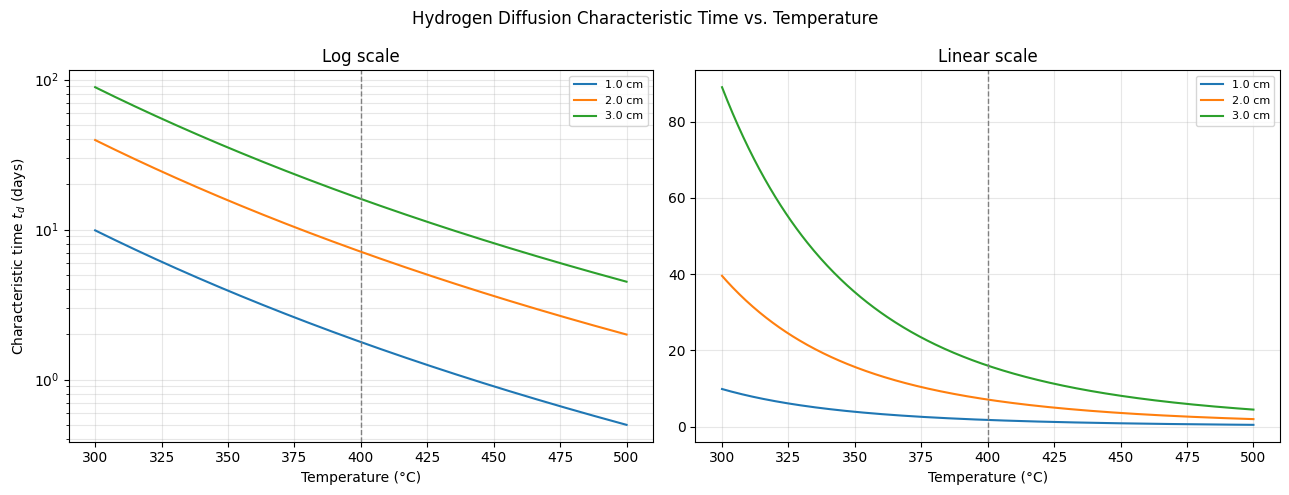

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Diffusion parameters for H in 304/316 stainless steel (Grant et al.)
D0 = 0.0122      # cm^2/s
ED = 0.57        # eV (activation energy)
k_B = 8.617e-5   # eV/K (Boltzmann constant)

def D(T_celsius):
    """Diffusion coefficient D(T) in cm^2/s. T_celsius can be a scalar or array."""
    T_kelvin = T_celsius + 273.15
    return D0 * np.exp(-ED / (k_B * T_kelvin))

def characteristic_time_days(T_celsius, thickness_cm):
    """Characteristic diffusion time t_d, in days, for a slab of given thickness."""
    t_d_seconds = thickness_cm**2 / (np.pi**2 * D(T_celsius))
    return t_d_seconds / 86400.0

# Temperature range to plot
T_range = np.linspace(300, 500, 400)  # degrees C

# A few representative wall thicknesses (cm)
thicknesses_cm = {
    "1.0 cm": 1.0,
    "2.0 cm": 2.0,
    "3.0 cm": 3.0,
}

fig, (ax_log, ax_lin) = plt.subplots(1, 2, figsize=(13, 5))

for label, d in thicknesses_cm.items():
    ax_log.semilogy(T_range, characteristic_time_days(T_range, d), label=label)
    ax_lin.plot(T_range, characteristic_time_days(T_range, d), label=label)

for ax, title in [(ax_log, "Log scale"), (ax_lin, "Linear scale")]:
    ax.axvline(400, color="gray", linestyle="--", linewidth=1)
    ax.set_xlabel("Temperature (°C)")
    ax.set_title(title)
    ax.grid(True, which="both", alpha=0.3)

ax_log.set_ylabel("Characteristic time $t_d$ (days)")
ax_log.legend(fontsize=8)
ax_lin.legend(fontsize=8)
fig.suptitle("Hydrogen Diffusion Characteristic Time vs. Temperature")
plt.tight_layout()
plt.show()

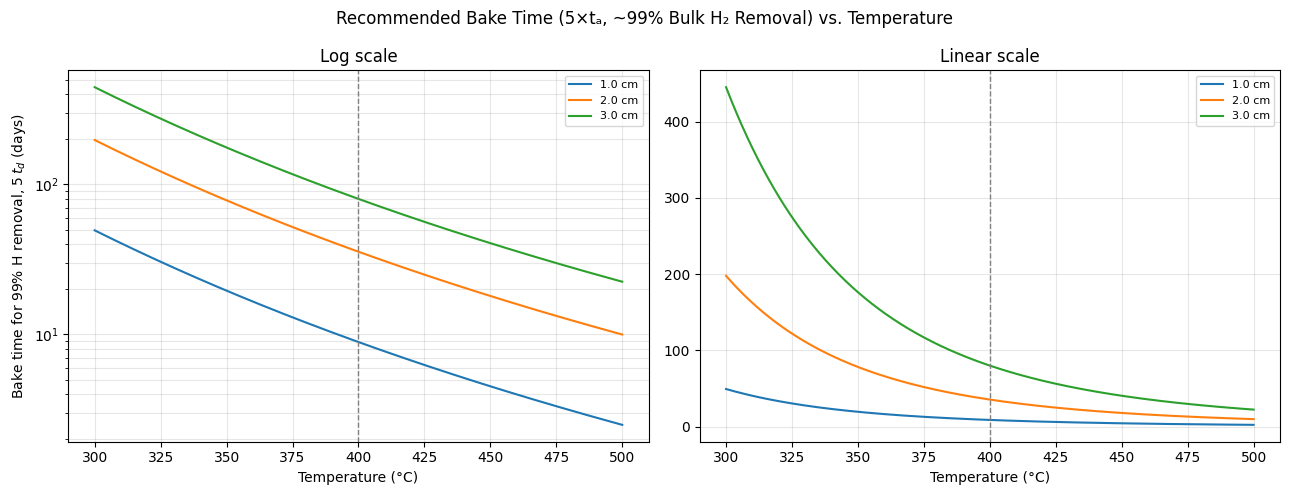

In [9]:
# now multiply by 5 to get the recommended bake time for ~99% H removal
fig, (ax_log, ax_lin) = plt.subplots(1, 2, figsize=(13, 5))

def bake_time_days(T_celsius, thickness_cm):
    """Recommended bake time for ~99% H removal, in days."""
    return 5 * characteristic_time_days(T_celsius, thickness_cm)

for label, d in thicknesses_cm.items():
    ax_log.semilogy(T_range, bake_time_days(T_range, d), label=label)
    ax_lin.plot(T_range, bake_time_days(T_range, d), label=label)

for ax, title in [(ax_log, "Log scale"), (ax_lin, "Linear scale")]:
    ax.axvline(400, color="gray", linestyle="--", linewidth=1)
    ax.set_xlabel("Temperature (°C)")
    ax.set_title(title)
    ax.grid(True, which="both", alpha=0.3)

ax_log.set_ylabel("Bake time for 99% H removal, $5\\,t_d$ (days)")
ax_log.legend(fontsize=8)
ax_lin.legend(fontsize=8)
fig.suptitle("Recommended Bake Time (5×tₐ, ~99% Bulk H₂ Removal) vs. Temperature")
plt.tight_layout()
plt.show()



## Now if we park the temperature at 400 C, how long does it take to bake out H for different thicknesses?
This one uses an approximate formula for the removal fraction.

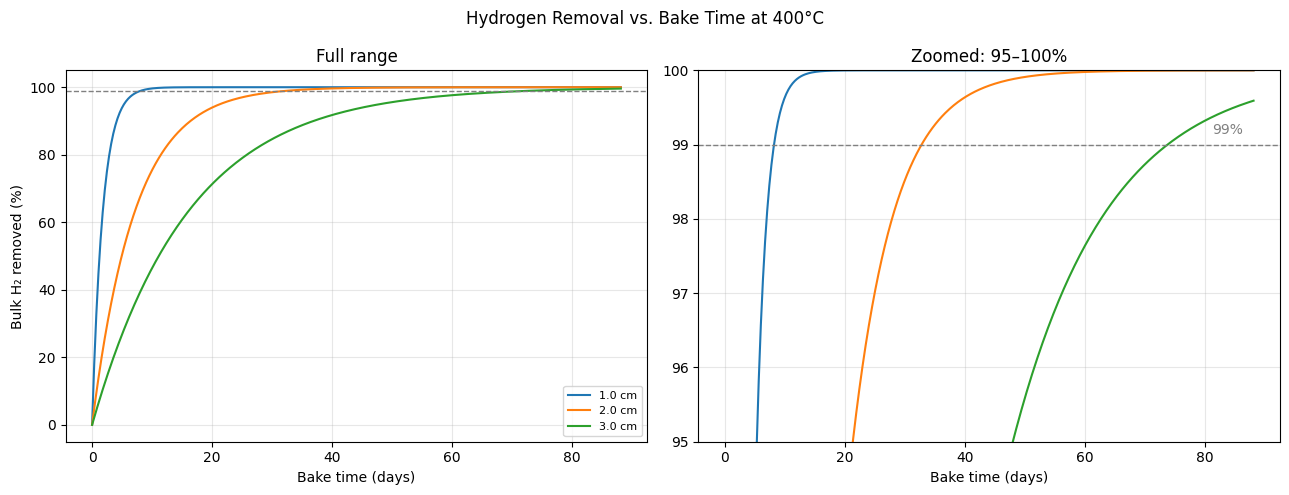

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Diffusion parameters for H in 304/316 stainless steel (Grant et al.)
D0 = 0.0122      # cm^2/s
ED = 0.57        # eV (activation energy)
k_B = 8.617e-5   # eV/K (Boltzmann constant)

def D(T_celsius):
    """Diffusion coefficient D(T) in cm^2/s."""
    T_kelvin = T_celsius + 273.15
    return D0 * np.exp(-ED / (k_B * T_kelvin))

def characteristic_time_days(T_celsius, thickness_cm):
    """Characteristic diffusion time t_d, in days."""
    t_d_seconds = thickness_cm**2 / (np.pi**2 * D(T_celsius))
    return t_d_seconds / 86400.0

def removal_fraction(t_days, t_d_days):
    """
    Fraction of bulk hydrogen removed after time t, using the leading-order
    diffusion solution: c(t)/c0 ~ exp(-t / t_d).
    This reproduces the literature rule of thumb that t = 5*t_d gives ~99% removal
    (exp(-5) = 0.0067, i.e. 99.3% removed).
    """
    return 1 - np.exp(-t_days / t_d_days)

# Fixed bake temperature
T_bake = 400  # degrees C

# A few representative wall thicknesses (cm)
thicknesses_cm = {
    "1.0 cm": 1.0,
    "2.0 cm": 2.0,
    "3.0 cm": 3.0,
}

# Time axis: go out to a bit past 5*t_d for the thickest part
t_d_max = characteristic_time_days(T_bake, max(thicknesses_cm.values()))
t_range_days = np.linspace(0, 5.5 * t_d_max, 500)

fig, (ax_full, ax_zoom) = plt.subplots(1, 2, figsize=(13, 5))

for label, d in thicknesses_cm.items():
    t_d = characteristic_time_days(T_bake, d)
    pct = 100 * removal_fraction(t_range_days, t_d)
    ax_full.plot(t_range_days, pct, label=label)
    ax_zoom.plot(t_range_days, pct, label=label)

for ax in (ax_full, ax_zoom):
    ax.axhline(99, color="gray", linestyle="--", linewidth=1)
    ax.set_xlabel("Bake time (days)")
    ax.grid(True, alpha=0.3)

ax_full.set_ylabel("Bulk H₂ removed (%)")
ax_full.set_title("Full range")
ax_full.legend(fontsize=8)

ax_zoom.set_ylim(95, 100)
ax_zoom.set_title("Zoomed: 95–100%")
ax_zoom.text(t_range_days[-1]*0.98, 99.1, "99%", ha="right", va="bottom", color="gray")

fig.suptitle(f"Hydrogen Removal vs. Bake Time at {T_bake}°C")
plt.tight_layout()
plt.show()

## Now if we park the temperature at 400 C, how long does it take to bake out H for different thicknesses?
This one uses the exact formula for the removal fraction.

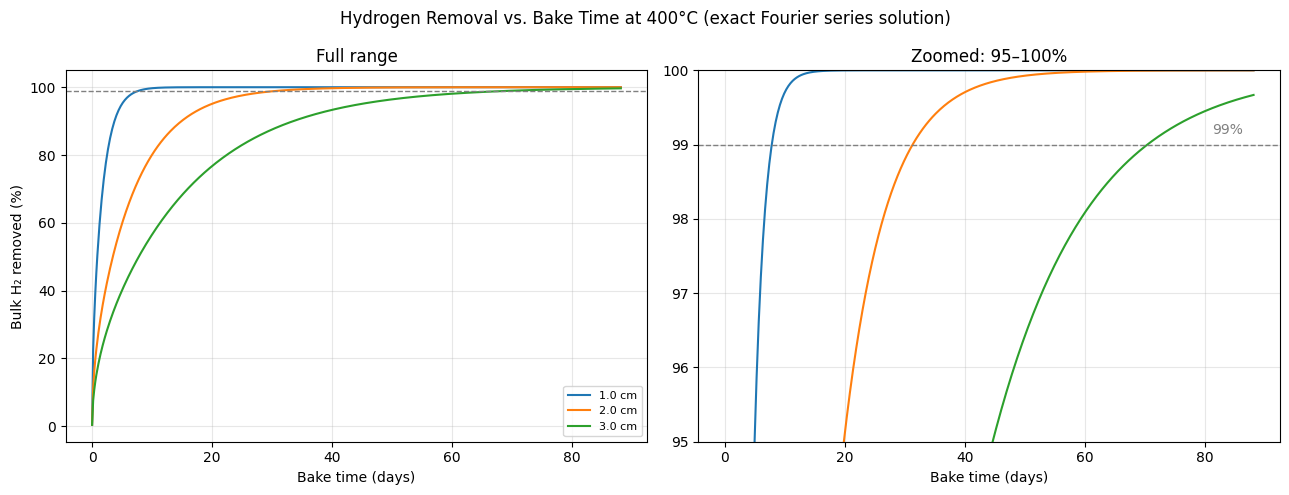

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# Diffusion parameters for H in 304/316 stainless steel (Grant et al.)
D0 = 0.0122      # cm^2/s
ED = 0.57        # eV (activation energy)
k_B = 8.617e-5   # eV/K (Boltzmann constant)

def D(T_celsius):
    """Diffusion coefficient D(T) in cm^2/s."""
    T_kelvin = T_celsius + 273.15
    return D0 * np.exp(-ED / (k_B * T_kelvin))

def characteristic_time_days(T_celsius, thickness_cm):
    """Characteristic diffusion time t_d, in days."""
    t_d_seconds = thickness_cm**2 / (np.pi**2 * D(T_celsius))
    return t_d_seconds / 86400.0

def removal_fraction_exact(t_days, t_d_days, n_terms=50):
    """
    Exact solution of Fick's second law for a slab of thickness d, held at
    zero concentration on both faces, starting from a uniform initial
    concentration c0 (Crank, "The Mathematics of Diffusion", plane sheet case).

    Fraction of bulk hydrogen REMAINING at time t:
        f_remain(t) = (8/pi^2) * sum_{n=0}^inf [1/(2n+1)^2] * exp(-(2n+1)^2 * t/t_d)

    Removal fraction is 1 - f_remain(t). The single-exponential approximation
    used previously is just the n=0 term of this series (without its 8/pi^2
    prefactor) -- this version sums the full series, so it's exact rather
    than a leading-order approximation.
    """
    t_days = np.asarray(t_days, dtype=float)
    f_remain = np.zeros_like(t_days)
    for n in range(n_terms):
        m = 2 * n + 1
        f_remain += (1.0 / m**2) * np.exp(-(m**2) * t_days / t_d_days)
    f_remain *= 8.0 / np.pi**2
    return 1 - f_remain

# Fixed bake temperature
T_bake = 400  # degrees C

# A few representative wall thicknesses (cm)
thicknesses_cm = {
    "1.0 cm": 1.0,
    "2.0 cm": 2.0,
    "3.0 cm": 3.0,
}

# Time axis: go out to a bit past 5*t_d for the thickest part
t_d_max = characteristic_time_days(T_bake, max(thicknesses_cm.values()))
t_range_days = np.linspace(0, 5.5 * t_d_max, 500)

fig, (ax_full, ax_zoom) = plt.subplots(1, 2, figsize=(13, 5))

for label, d in thicknesses_cm.items():
    t_d = characteristic_time_days(T_bake, d)
    pct = 100 * removal_fraction_exact(t_range_days, t_d)
    ax_full.plot(t_range_days, pct, label=label)
    ax_zoom.plot(t_range_days, pct, label=label)

for ax in (ax_full, ax_zoom):
    ax.axhline(99, color="gray", linestyle="--", linewidth=1)
    ax.set_xlabel("Bake time (days)")
    ax.grid(True, alpha=0.3)

ax_full.set_ylabel("Bulk H₂ removed (%)")
ax_full.set_title("Full range")
ax_full.legend(fontsize=8)

ax_zoom.set_ylim(95, 100)
ax_zoom.set_title("Zoomed: 95–100%")
ax_zoom.text(t_range_days[-1]*0.98, 99.1, "99%", ha="right", va="bottom", color="gray")

fig.suptitle(f"Hydrogen Removal vs. Bake Time at {T_bake}°C (exact Fourier series solution)")
plt.tight_layout()
plt.show()